In [1]:
import pandas as pd
import numpy as np
import os
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm # Assuming tqdm is imported

In [2]:
train_df = pd.read_csv("../Datasets/train.csv")
val_df = pd.read_csv("../Datasets/val.csv")
test_df = pd.read_csv("../Datasets/test.csv")
PROC_DIR = "."
print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

Train samples: 36916
Validation samples: 6515
Test samples: 7665


In [3]:
# --- FIX: Re-encode the string labels to integers after reading CSVs ---
le = LabelEncoder()

In [4]:
all_labels = pd.concat([train_df['label'], val_df['label'], test_df['label']])
le.fit(all_labels)

LabelEncoder()

In [5]:
# Apply the transformation back to the dataframes' 'label' column
train_df['label'] = le.transform(train_df['label'])
val_df['label'] = le.transform(val_df['label'])
test_df['label'] = le.transform(test_df['label'])

In [6]:
# ---------------- Keypoint Augmentation Helpers ------------------
def random_scaling(x_seq, scale_range=(0.9, 1.1)):
    s = np.random.uniform(scale_range[0], scale_range[1])
    return x_seq * s

def random_rotation(x_seq, max_angle=10):
    theta = np.radians(np.random.uniform(-max_angle, max_angle))
    cos_val, sin_val = np.cos(theta), np.sin(theta)
    R = np.array([[cos_val, -sin_val, 0],
                  [sin_val, cos_val, 0],
                  [0, 0, 1]], dtype=np.float32)
    T = x_seq.shape[0]
    x_reshaped = x_seq.reshape(T, 129, 3)
    x_rotated = np.dot(x_reshaped, R.T)
    return x_rotated.reshape(T, -1)

def add_noise(x_seq, noise_level=0.01):
    noise = np.random.normal(0, noise_level, x_seq.shape)
    mask = (x_seq != 0.0)
    x_seq[mask] += noise[mask]
    return x_seq

def augment_sequence(x_seq):
    if np.random.rand() < 0.5:
        x_seq = random_scaling(x_seq)
    if np.random.rand() < 0.5:
        x_seq = random_rotation(x_seq)
    if np.random.rand() < 0.5:
        x_seq = add_noise(x_seq)
    return x_seq

# ---------------- Dataset Loader with Augmentation ------------------
class SignDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df
        self.augment = augment

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = np.load(f"{PROC_DIR}/{row.file}").astype(np.float32)
        
        if self.augment:
            x = augment_sequence(x)
            
        y = int(row.label)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.df)


In [7]:
train_loader = DataLoader(SignDataset(train_df, augment=True), batch_size=32, shuffle=True)
val_loader   = DataLoader(SignDataset(val_df, augment=False),   batch_size=32, shuffle=False)
test_loader  = DataLoader(SignDataset(test_df, augment=False),  batch_size=32, shuffle=False)


In [8]:
sample_batch_X, sample_batch_y = next(iter(train_loader))
input_dim = sample_batch_X.shape[-1] # Gets the actual last dimension: 387

num_classes = train_df.label.nunique()
print(f"Dynamically determined input_dim: {input_dim}")
print(f"Number of classes: {num_classes}")

Dynamically determined input_dim: 387
Number of classes: 401


In [9]:
# ---------------- Model ---------------------------
input_dim = (54+21+21+33) * 3   # face + lh + rh + pose (x,y,z)
num_classes = train_df.label.nunique()

class TransformerSignModel(nn.Module):
    def __init__(self, input_dim=387, num_classes=401, d_model=256, nhead=8, num_layers=3, dropout=0.3):
        super().__init__()
        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU()
        )
        self.pos_encoder = nn.Parameter(torch.randn(1, 60, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4, 
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        B, T, F = x.shape
        x = self.input_projection(x)
        x = x + self.pos_encoder[:, :T, :]
        x = self.transformer_encoder(x)
        x = torch.mean(x, dim=1)
        return self.fc(x)


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model = TransformerSignModel(input_dim, num_classes).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Using device: cuda


In [10]:
# ---------------- EarlyStopping Class (Directory Aware) -----------------------
class EarlyStopping:
    """Stops training when validation loss does not improve for a given patience."""
    def __init__(self, patience=5, verbose=False, delta=0, filename='checkpoint.pt', save_dir='Models'):
        self.patience = patience
        self.verbose = verbose
        self.delta = delta
        self.save_dir = save_dir
        # Combine directory and filename for the full path
        self.path = os.path.join(save_dir, filename) 
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        
        # Ensure the save directory exists before any saving happens
        if not os.path.exists(self.save_dir):
            os.makedirs(self.save_dir, exist_ok=True)
            if self.verbose:
                print(f"Created directory: {self.save_dir}")

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        """Saves model when validation loss decreases."""
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model to {self.path}...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [11]:
# ---------------- Training Loop with Early Stopping -------------------
EPOCHS = 150
train_losses, val_losses = [], []
train_accs, val_accs = [], []

# Initialize Early Stopping, configuring it to use the final desired path
early_stopping = EarlyStopping(
    patience=7, 
    verbose=True,
    save_dir='../Models',          # Saves to the parent directory's 'Models' folder
    filename='transformer_frontveiw.pth'   # Desired filename
)

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct = 0, 0

    for X, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        preds = model(X)
        loss = loss_fn(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (preds.argmax(1) == y).sum().item()

    train_losses.append(total_loss)
    train_accs.append(correct / len(train_df))


    # ---------------- Validation ----------------
    model.eval()
    v_loss, v_correct = 0, 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            preds = model(X)
            v_loss += loss_fn(preds, y).item()
            v_correct += (preds.argmax(1) == y).sum().item()

    # Calculate average validation loss for the epoch
    avg_val_loss = v_loss / len(val_loader) 
    val_losses.append(avg_val_loss) # Note: appending average loss
    val_accs.append(v_correct / len(val_df))

    print(f"Epoch {epoch+1}: Train Loss={total_loss:.4f}, Val Loss={avg_val_loss:.4f}, Train Acc={train_accs[-1]:.4f}, Val Acc={val_accs[-1]:.4f}")

    # Check early stopping condition (saves best model automatically)
    early_stopping(avg_val_loss, model)

    if early_stopping.early_stop:
        print("Early stopping triggered. Breaking training loop.")
        break

Epoch 1/150: 100%|██████████| 1154/1154 [01:22<00:00, 14.05it/s]


Epoch 1: Train Loss=6213.7713, Val Loss=4.4487, Train Acc=0.0304, Val Acc=0.0965
Validation loss decreased (inf --> 4.448653). Saving model to ../Models\transformer_bdslw401.pth...


Epoch 2/150: 100%|██████████| 1154/1154 [01:29<00:00, 12.86it/s]


Epoch 2: Train Loss=4426.9106, Val Loss=3.1517, Train Acc=0.1889, Val Acc=0.2807
Validation loss decreased (4.448653 --> 3.151727). Saving model to ../Models\transformer_bdslw401.pth...


Epoch 3/150: 100%|██████████| 1154/1154 [01:31<00:00, 12.63it/s]


Epoch 3: Train Loss=3212.0196, Val Loss=2.3456, Train Acc=0.3717, Val Acc=0.4193
Validation loss decreased (3.151727 --> 2.345580). Saving model to ../Models\transformer_bdslw401.pth...


Epoch 4/150: 100%|██████████| 1154/1154 [01:37<00:00, 11.81it/s]


Epoch 4: Train Loss=2404.1382, Val Loss=1.7444, Train Acc=0.5073, Val Acc=0.5509
Validation loss decreased (2.345580 --> 1.744435). Saving model to ../Models\transformer_bdslw401.pth...


Epoch 5/150: 100%|██████████| 1154/1154 [01:37<00:00, 11.88it/s]


Epoch 5: Train Loss=1842.0646, Val Loss=1.3686, Train Acc=0.6103, Val Acc=0.6359
Validation loss decreased (1.744435 --> 1.368611). Saving model to ../Models\transformer_bdslw401.pth...


Epoch 6/150: 100%|██████████| 1154/1154 [01:41<00:00, 11.36it/s]


Epoch 6: Train Loss=1462.2670, Val Loss=1.1206, Train Acc=0.6849, Val Acc=0.7024
Validation loss decreased (1.368611 --> 1.120557). Saving model to ../Models\transformer_bdslw401.pth...


Epoch 7/150: 100%|██████████| 1154/1154 [01:45<00:00, 10.95it/s]


Epoch 7: Train Loss=1186.6962, Val Loss=0.9752, Train Acc=0.7394, Val Acc=0.7318
Validation loss decreased (1.120557 --> 0.975177). Saving model to ../Models\transformer_bdslw401.pth...


Epoch 8/150: 100%|██████████| 1154/1154 [01:20<00:00, 14.42it/s]


Epoch 8: Train Loss=982.0375, Val Loss=0.8462, Train Acc=0.7771, Val Acc=0.7670
Validation loss decreased (0.975177 --> 0.846184). Saving model to ../Models\transformer_bdslw401.pth...


Epoch 9/150: 100%|██████████| 1154/1154 [01:33<00:00, 12.34it/s]


Epoch 9: Train Loss=830.5276, Val Loss=0.7554, Train Acc=0.8128, Val Acc=0.7784
Validation loss decreased (0.846184 --> 0.755406). Saving model to ../Models\transformer_bdslw401.pth...


Epoch 10/150: 100%|██████████| 1154/1154 [02:00<00:00,  9.56it/s]


Epoch 10: Train Loss=707.8561, Val Loss=0.7117, Train Acc=0.8385, Val Acc=0.7991
Validation loss decreased (0.755406 --> 0.711694). Saving model to ../Models\transformer_bdslw401.pth...


Epoch 11/150: 100%|██████████| 1154/1154 [02:10<00:00,  8.85it/s]


Epoch 11: Train Loss=614.5248, Val Loss=0.6460, Train Acc=0.8582, Val Acc=0.8221
Validation loss decreased (0.711694 --> 0.645975). Saving model to ../Models\transformer_bdslw401.pth...


Epoch 12/150: 100%|██████████| 1154/1154 [02:05<00:00,  9.16it/s]


Epoch 12: Train Loss=535.3903, Val Loss=0.5359, Train Acc=0.8735, Val Acc=0.8483
Validation loss decreased (0.645975 --> 0.535850). Saving model to ../Models\transformer_bdslw401.pth...


Epoch 13/150: 100%|██████████| 1154/1154 [02:05<00:00,  9.17it/s]


Epoch 13: Train Loss=467.5038, Val Loss=0.5276, Train Acc=0.8894, Val Acc=0.8491
Validation loss decreased (0.535850 --> 0.527634). Saving model to ../Models\transformer_bdslw401.pth...


Epoch 14/150: 100%|██████████| 1154/1154 [02:00<00:00,  9.56it/s]


Epoch 14: Train Loss=409.0575, Val Loss=0.5776, Train Acc=0.9043, Val Acc=0.8353
EarlyStopping counter: 1 of 7


Epoch 15/150: 100%|██████████| 1154/1154 [02:00<00:00,  9.56it/s]


Epoch 15: Train Loss=360.1847, Val Loss=0.4885, Train Acc=0.9141, Val Acc=0.8635
Validation loss decreased (0.527634 --> 0.488483). Saving model to ../Models\transformer_bdslw401.pth...


Epoch 16/150: 100%|██████████| 1154/1154 [01:59<00:00,  9.65it/s]


Epoch 16: Train Loss=326.2846, Val Loss=0.4603, Train Acc=0.9228, Val Acc=0.8694
Validation loss decreased (0.488483 --> 0.460320). Saving model to ../Models\transformer_bdslw401.pth...


Epoch 17/150: 100%|██████████| 1154/1154 [01:54<00:00, 10.09it/s]


Epoch 17: Train Loss=283.6053, Val Loss=0.4628, Train Acc=0.9340, Val Acc=0.8749
EarlyStopping counter: 1 of 7


Epoch 18/150: 100%|██████████| 1154/1154 [01:50<00:00, 10.44it/s]


Epoch 18: Train Loss=258.6756, Val Loss=0.4471, Train Acc=0.9362, Val Acc=0.8786
Validation loss decreased (0.460320 --> 0.447117). Saving model to ../Models\transformer_bdslw401.pth...


Epoch 19/150: 100%|██████████| 1154/1154 [01:48<00:00, 10.62it/s]


Epoch 19: Train Loss=236.3825, Val Loss=0.4513, Train Acc=0.9428, Val Acc=0.8772
EarlyStopping counter: 1 of 7


Epoch 20/150: 100%|██████████| 1154/1154 [01:48<00:00, 10.62it/s]


Epoch 20: Train Loss=212.8314, Val Loss=0.4139, Train Acc=0.9484, Val Acc=0.8886
Validation loss decreased (0.447117 --> 0.413919). Saving model to ../Models\transformer_bdslw401.pth...


Epoch 21/150: 100%|██████████| 1154/1154 [01:50<00:00, 10.45it/s]


Epoch 21: Train Loss=190.8954, Val Loss=0.4409, Train Acc=0.9544, Val Acc=0.8803
EarlyStopping counter: 1 of 7


Epoch 22/150: 100%|██████████| 1154/1154 [01:49<00:00, 10.55it/s]


Epoch 22: Train Loss=182.5071, Val Loss=0.4309, Train Acc=0.9554, Val Acc=0.8901
EarlyStopping counter: 2 of 7


Epoch 23/150: 100%|██████████| 1154/1154 [01:50<00:00, 10.44it/s]


Epoch 23: Train Loss=157.2646, Val Loss=0.3932, Train Acc=0.9625, Val Acc=0.8973
Validation loss decreased (0.413919 --> 0.393176). Saving model to ../Models\transformer_bdslw401.pth...


Epoch 24/150: 100%|██████████| 1154/1154 [01:49<00:00, 10.57it/s]


Epoch 24: Train Loss=152.3329, Val Loss=0.4098, Train Acc=0.9635, Val Acc=0.8949
EarlyStopping counter: 1 of 7


Epoch 25/150: 100%|██████████| 1154/1154 [01:49<00:00, 10.52it/s]


Epoch 25: Train Loss=135.3228, Val Loss=0.4112, Train Acc=0.9680, Val Acc=0.8932
EarlyStopping counter: 2 of 7


Epoch 26/150: 100%|██████████| 1154/1154 [01:45<00:00, 10.94it/s]


Epoch 26: Train Loss=126.2860, Val Loss=0.4294, Train Acc=0.9696, Val Acc=0.8890
EarlyStopping counter: 3 of 7


Epoch 27/150: 100%|██████████| 1154/1154 [01:35<00:00, 12.04it/s]


Epoch 27: Train Loss=119.5329, Val Loss=0.4127, Train Acc=0.9713, Val Acc=0.8998
EarlyStopping counter: 4 of 7


Epoch 28/150: 100%|██████████| 1154/1154 [01:37<00:00, 11.82it/s]


Epoch 28: Train Loss=110.3314, Val Loss=0.3897, Train Acc=0.9735, Val Acc=0.9039
Validation loss decreased (0.393176 --> 0.389739). Saving model to ../Models\transformer_bdslw401.pth...


Epoch 29/150: 100%|██████████| 1154/1154 [01:37<00:00, 11.87it/s]


Epoch 29: Train Loss=109.8752, Val Loss=0.4017, Train Acc=0.9727, Val Acc=0.9039
EarlyStopping counter: 1 of 7


Epoch 30/150: 100%|██████████| 1154/1154 [01:41<00:00, 11.32it/s]


Epoch 30: Train Loss=101.2007, Val Loss=0.4523, Train Acc=0.9755, Val Acc=0.8893
EarlyStopping counter: 2 of 7


Epoch 31/150: 100%|██████████| 1154/1154 [01:37<00:00, 11.79it/s]


Epoch 31: Train Loss=97.1326, Val Loss=0.3962, Train Acc=0.9761, Val Acc=0.9059
EarlyStopping counter: 3 of 7


Epoch 32/150: 100%|██████████| 1154/1154 [01:41<00:00, 11.38it/s]


Epoch 32: Train Loss=89.0676, Val Loss=0.4802, Train Acc=0.9781, Val Acc=0.8844
EarlyStopping counter: 4 of 7


Epoch 33/150: 100%|██████████| 1154/1154 [01:55<00:00,  9.96it/s]


Epoch 33: Train Loss=87.2640, Val Loss=0.3992, Train Acc=0.9785, Val Acc=0.9071
EarlyStopping counter: 5 of 7


Epoch 34/150: 100%|██████████| 1154/1154 [02:16<00:00,  8.46it/s]


Epoch 34: Train Loss=82.0325, Val Loss=0.4183, Train Acc=0.9798, Val Acc=0.9045
EarlyStopping counter: 6 of 7


Epoch 35/150: 100%|██████████| 1154/1154 [01:40<00:00, 11.50it/s]


Epoch 35: Train Loss=81.8517, Val Loss=0.4361, Train Acc=0.9803, Val Acc=0.9012
EarlyStopping counter: 7 of 7
Early stopping triggered. Breaking training loop.


In [12]:
# After training completes, load the best model weights that were saved by EarlyStopping
model.load_state_dict(torch.load(early_stopping.path))

<All keys matched successfully>

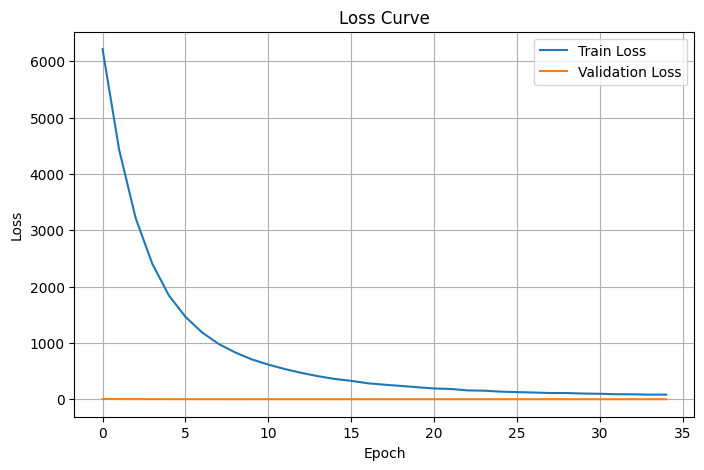

In [13]:
# -------- Plot Training vs Validation Loss ------------
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()

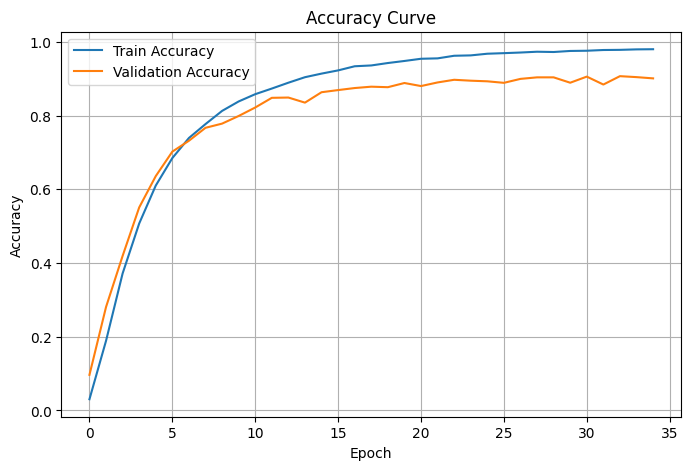

In [14]:
# -------- Plot Training vs Validation Accuracy ---------
plt.figure(figsize=(8,5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()
plt.show()

In [15]:
#                   TESTING & METRICS

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        preds = model(X)
        all_preds.extend(preds.argmax(1).cpu().numpy())
        all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)



<Figure size 4200x3600 with 0 Axes>

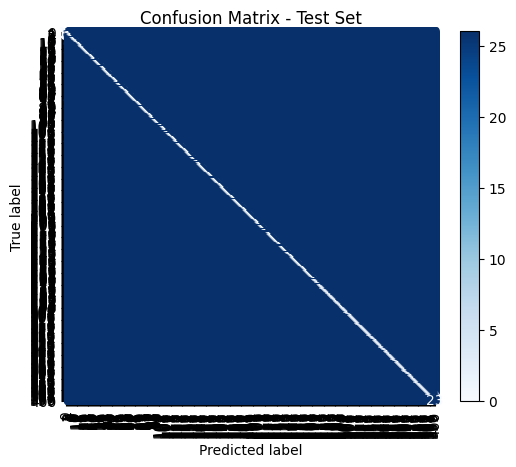


Classification Report:
              precision    recall  f1-score   support

           0       0.79      1.00      0.88        19
           1       0.95      0.95      0.95        19
           2       1.00      0.80      0.89        20
           3       0.95      0.90      0.92        20
           4       0.92      0.58      0.71        19
           5       0.95      0.90      0.92        20
           6       1.00      1.00      1.00        20
           7       0.95      0.95      0.95        20
           8       0.90      0.90      0.90        20
           9       1.00      1.00      1.00        19
          10       0.78      0.37      0.50        19
          11       0.71      0.79      0.75        19
          12       1.00      0.83      0.91        18
          13       1.00      1.00      1.00        20
          14       1.00      0.74      0.85        19
          15       0.68      0.94      0.79        18
          16       0.83      1.00      0.91        20
   

In [16]:
# ---------------- Confusion Matrix ----------------
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(42,36))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation='vertical')
plt.title("Confusion Matrix - Test Set")
plt.show()

# ---------------- Classification Report -------------
print("\nClassification Report:")
print(classification_report(all_labels, all_preds))